[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dz-web3/DS-Tech-2026spring/blob/main/Module8_LLM_Finetuning/Task1_Sentiment_Finetuning.ipynb)

# Task 1: Fine-Tuning for Sentiment Analysis

**Data Science for Business (Technical) — Spring 2026**

---

## Learning Goals

In this task, you will:
1. **Run** a working sentiment classification model fine-tuned on product reviews
2. **Add** your own training examples to customize the model
3. **Test** the model on your own text to see how it performs
4. **Reflect** on when fine-tuning is the right business choice

---

## What You Need to Do

1. **First**: Run all the cells from top to bottom to see the demo
2. **Then**: Complete the 3 exercises marked below
3. **Finally**: Answer the reflection questions at the end

**Estimated time**: 20-30 minutes

## Step 1: Setup (Just Run This Cell)

In [1]:
# Check GPU availability
import torch
if torch.cuda.is_available():
    print(f"GPU enabled: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Go to Runtime → Change runtime type")

GPU enabled: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
%%capture
# Install required libraries (this takes ~1 minute)
!pip install transformers datasets evaluate accelerate -q

In [3]:
# Import libraries
from transformers import (
AutoTokenizer,
AutoModelForSequenceClassification,
TrainingArguments,
Trainer
)
from datasets import Dataset
import evaluate
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2: Prepare Training Data

We'll train the model to classify product reviews as **positive** (1) or **negative** (0).

Just like in the main notebook, we split our data into:
- **Training data**: Used to fine-tune the model
- **Test data**: Held out to check if the model actually learned (not just memorized)

In [4]:
# Training data: Product reviews with sentiment labels
# label = 1 means POSITIVE, label = 0 means NEGATIVE

training_examples = [
    # POSITIVE reviews (label = 1)
    {"text": "This product exceeded my expectations! Absolutely love it.", "label": 1},
    {"text": "Great quality for the price. Would definitely buy again.", "label": 1},
    {"text": "Fast shipping and the item works perfectly. Very satisfied!", "label": 1},
    {"text": "Best purchase I've made this year. Highly recommend!", "label": 1},
    {"text": "The customer service was amazing and the product is fantastic.", "label": 1},
    {"text": "Exactly what I needed. Works as described.", "label": 1},

    # NEGATIVE reviews (label = 0)
    {"text": "Terrible quality. Broke after one week of use.", "label": 0},
    {"text": "Waste of money. Does not work as advertised.", "label": 0},
    {"text": "Very disappointed. Would not recommend to anyone.", "label": 0},
    {"text": "Poor quality and awful customer service.", "label": 0},
    {"text": "Arrived damaged and getting a refund was a nightmare.", "label": 0},
    {"text": "Complete scam. Nothing like the pictures showed.", "label": 0},
]

# Test data: The model NEVER sees these during training
# We use 8 examples (not 4) so that accuracy is more meaningful —
# with only 4 examples, getting 1 wrong = 25% accuracy drop!
test_examples = [
    {"text": "Love this product! My whole family uses it now.", "label": 1},
    {"text": "Five stars! Couldn't be happier with my purchase.", "label": 1},
    {"text": "Solid build quality and great value for the money.", "label": 1},
    {"text": "Works like a charm right out of the box.", "label": 1},
    {"text": "Don't buy this. Regret wasting my money.", "label": 0},
    {"text": "Stopped working after two days. Total junk.", "label": 0},
    {"text": "Cheaply made and falls apart easily. Avoid.", "label": 0},
    {"text": "Misleading product description. Very unhappy.", "label": 0},
]

print(f"Training data: {len(training_examples)} examples")
print(f"  - Positive: {sum(1 for x in training_examples if x['label'] == 1)}")
print(f"  - Negative: {sum(1 for x in training_examples if x['label'] == 0)}")
print(f"Test data: {len(test_examples)} examples (held out)")
print(f"  - Positive: {sum(1 for x in test_examples if x['label'] == 1)}")
print(f"  - Negative: {sum(1 for x in test_examples if x['label'] == 0)}")

Training data: 12 examples
  - Positive: 6
  - Negative: 6
Test data: 8 examples (held out)
  - Positive: 4
  - Negative: 4


## Step 3: Load the Pre-trained Model

We'll use **DistilBERT** — a smaller, faster version of BERT that's perfect for learning.

### Pre-trained for what, exactly?

DistilBERT was pre-trained on **masked language modeling (MLM)** — the model sees sentences with random words hidden, and learns to fill in the blanks:

```
Input:  "The customer was very [MASK] with the product"
Model:  "The customer was very HAPPY with the product"  ← predicted
```

By doing this millions of times, the model learns what words mean, how grammar works, and how sentences are structured. But it has **no idea** what "positive" or "negative" sentiment is — that's not what it was trained for.

### Swapping the head for classification

To use DistilBERT for sentiment classification, we **remove** the word-prediction head (the layers that guess masked words) and **replace** it with a new classification head (two small layers that output "positive" or "negative"):

```
Pre-trained DistilBERT          What we load here
─────────────────────          ─────────────────────
 Encoder (understands    →      Encoder (SAME — keeps
 language)                      all its knowledge)

 MLM Head (predicts      →      Classification Head
 masked words)                  (positive vs negative)
 ▲ UNEXPECTED keys              ▲ MISSING keys
   (discarded)                    (randomly initialized)
```

This is why you'll see "UNEXPECTED" and "MISSING" keys in the output below — it's the head swap in action.

In [5]:
# Load tokenizer and model
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
model_name,
num_labels=2, # 2 classes: positive and negative
id2label={0: "NEGATIVE", 1: "POSITIVE"},
label2id={"NEGATIVE": 0, "POSITIVE": 1}
)

print(f"Model loaded: {model_name}")
print(f"Parameters: ~66 million")
print()
print("NOTE: The 'LOAD REPORT' above is normal and expected!")
print("  - UNEXPECTED keys (vocab_layer_norm, vocab_projector, etc.):")
print("    These belong to DistilBERT's original task (predicting masked words).")
print("    We don't need them for classification, so they are safely ignored.")
print("  - MISSING keys (pre_classifier, classifier):")
print("    These are the NEW classification layers we're adding on top.")
print("    They start with random weights — training will teach them.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Parameters: ~66 million

NOTE: The 'LOAD REPORT' above is normal and expected!
  - UNEXPECTED keys (vocab_layer_norm, vocab_projector, etc.):
    These belong to DistilBERT's original task (predicting masked words).
    We don't need them for classification, so they are safely ignored.
  - MISSING keys (pre_classifier, classifier):
    These are the NEW classification layers we're adding on top.
    They start with random weights — training will teach them.


### How This Fine-Tuning Works (vs. LoRA in the Main Notebook)

In the main notebook, we used **LoRA** — freezing 99% of the model and training tiny adapter matrices (~1% of parameters).

Here in Task 1, we do something simpler: **full fine-tuning**.

| | Main Notebook (LoRA) | Task 1 (Full Fine-Tuning) |
|---|---|---|
| **Base model** | Qwen2.5-0.5B (text generation) | DistilBERT (text understanding) |
| **What's added** | Small LoRA adapter matrices inside attention layers | A classification head (2 small layers) on top |
| **What's trained** | Only the LoRA adapters (~1% of params) | **Everything** — all 66M parameters |
| **Training data** | 100 examples | 12 examples |

#### What does "classification head" mean?

DistilBERT was pre-trained to *understand* language (by predicting masked words). But it doesn't know how to *classify* sentiment. So we add two small layers on top:

```
DistilBERT encoder (66M params, pre-trained)
    → Pre-classifier layer (randomly initialized)
        → Classifier layer (randomly initialized, 2 outputs: positive/negative)
```

When we run `Trainer.train()`, **all** parameters are updated — both the pre-trained encoder and the new head. With only 12 training examples updating 66M parameters, the model may barely learn — we'll see how much impact such a small dataset actually has.

> **Key takeaway**: More training data → better learning. In the main notebook we used 100 examples; here we use only 12. Exercise 1 lets you add more and see the difference.

### Baseline: How Does the Model Perform BEFORE Training?

The model we just loaded (DistilBERT) was pre-trained on general English text, but its classification head is **randomly initialized** — it has never been trained to classify sentiment. Let's see how it performs before we teach it.

In [6]:
# Define prediction function (we'll reuse this after training too)
def predict_sentiment(text):
    """Predict sentiment of a given text"""
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
        confidence = torch.softmax(outputs.logits, dim=-1).max().item()

    sentiment = "POSITIVE" if prediction == 1 else "NEGATIVE"
    return sentiment, confidence

# Run baseline on test data BEFORE training
print("BASELINE (before training):")
print("=" * 60)
baseline_results = []
for ex in test_examples:
    sentiment, confidence = predict_sentiment(ex['text'])
    expected = "POSITIVE" if ex['label'] == 1 else "NEGATIVE"
    correct = sentiment == expected
    baseline_results.append({'text': ex['text'], 'predicted': sentiment, 'expected': expected,
                             'confidence': confidence, 'correct': correct})
    status = "correct" if correct else "WRONG"
    print(f"  \"{ex['text'][:60]}...\"")
    print(f"    Predicted: {sentiment} ({confidence:.1%}) | Expected: {expected} | {status}")

baseline_accuracy = sum(r['correct'] for r in baseline_results) / len(baseline_results)
baseline_avg_conf = sum(r['confidence'] for r in baseline_results) / len(baseline_results)
print(f"\nBaseline accuracy: {baseline_accuracy:.0%}")
print(f"Average confidence: {baseline_avg_conf:.1%}")
print(f"\nThe model's confidence is only ~{baseline_avg_conf:.0%} -- barely above a coin flip!")
print("It may get some right by luck, but it has no real understanding of sentiment. Let's fix that.")

BASELINE (before training):
  "Love this product! My whole family uses it now...."
    Predicted: NEGATIVE (50.4%) | Expected: POSITIVE | WRONG
  "Five stars! Couldn't be happier with my purchase...."
    Predicted: POSITIVE (50.5%) | Expected: POSITIVE | correct
  "Solid build quality and great value for the money...."
    Predicted: NEGATIVE (51.8%) | Expected: POSITIVE | WRONG
  "Works like a charm right out of the box...."
    Predicted: NEGATIVE (50.5%) | Expected: POSITIVE | WRONG
  "Don't buy this. Regret wasting my money...."
    Predicted: POSITIVE (50.6%) | Expected: NEGATIVE | WRONG
  "Stopped working after two days. Total junk...."
    Predicted: POSITIVE (51.4%) | Expected: NEGATIVE | WRONG
  "Cheaply made and falls apart easily. Avoid...."
    Predicted: POSITIVE (51.3%) | Expected: NEGATIVE | WRONG
  "Misleading product description. Very unhappy...."
    Predicted: POSITIVE (50.0%) | Expected: NEGATIVE | WRONG

Baseline accuracy: 12%
Average confidence: 50.8%

The model'

**What does "confidence" mean here?**

The classification head outputs two raw scores (logits) — one for POSITIVE, one for NEGATIVE. We apply **softmax** to convert them into probabilities that sum to 100%. The higher of the two is the "confidence."

- **50%** = coin flip — the model assigns equal probability to both classes
- **90%+** = the model strongly favors one class

Confidence tells you *how sure* the model is, which is separate from whether it's actually *correct*.

## Step 4: Prepare Data for Training

In [7]:
# Convert to Hugging Face Dataset format
dataset = Dataset.from_list(training_examples)

# Tokenize the text
def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(tokenize, batched=True)

print("Data tokenized and ready for training!")

Map:   0%|          | 0/12 [00:00<?, ? examples/s]

Data tokenized and ready for training!


In [8]:
# Let's see what tokenization actually looks like
# This is how text gets converted to numbers the model can process

example_text = training_examples[0]['text']
tokens = tokenizer(example_text, return_tensors=None, truncation=True, padding="max_length", max_length=128)

print(f"Original text: \"{example_text}\"")
print(f"\nTokenized representation:")
print(f"  Token IDs (first 15):    {tokens['input_ids'][:15]}")
print(f"  Attention mask (first 15): {tokens['attention_mask'][:15]}")

# Decode individual tokens to see how words are split
word_tokens = tokenizer.tokenize(example_text)
print(f"\n  Subword tokens: {word_tokens}")
print(f"  Total tokens: {len(word_tokens)}")

# Show padding
num_real = sum(tokens['attention_mask'])
num_pad = len(tokens['attention_mask']) - num_real
print(f"\n  Real tokens: {num_real} | Padding tokens: {num_pad} (to fill max_length=128)")
print(f"  Attention mask: 1 = real token, 0 = padding (model ignores these)")

Original text: "This product exceeded my expectations! Absolutely love it."

Tokenized representation:
  Token IDs (first 15):    [101, 2023, 4031, 14872, 2026, 10908, 999, 7078, 2293, 2009, 1012, 102, 0, 0, 0]
  Attention mask (first 15): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]

  Subword tokens: ['this', 'product', 'exceeded', 'my', 'expectations', '!', 'absolutely', 'love', 'it', '.']
  Total tokens: 10

  Real tokens: 12 | Padding tokens: 116 (to fill max_length=128)
  Attention mask: 1 = real token, 0 = padding (model ignores these)


## Step 5: Train the Model

This will take about **2-3 minutes**. Watch the loss decrease!

In [9]:
# Define evaluation metric
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Prepare test dataset for evaluation
test_dataset = Dataset.from_list(test_examples)
tokenized_test = test_dataset.map(tokenize, batched=True)

# Training configuration
training_args = TrainingArguments(
    output_dir="./sentiment_model",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    learning_rate=2e-5,
    logging_steps=1,      # Log every step for a smooth loss curve
    save_strategy="no",
    report_to="none",
)

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Starting training...")
print(f"  {len(tokenized_dataset)} training examples, batch size 4 → {len(tokenized_dataset)//4} steps per epoch")
print(f"  5 epochs → {5 * (len(tokenized_dataset)//4)} total training steps")
print("  Watch the 'loss' value decrease — that means the model is learning!\n")

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Starting training...
  12 training examples, batch size 4 → 3 steps per epoch
  5 epochs → 15 total training steps
  Watch the 'loss' value decrease — that means the model is learning!



In [10]:
# Train the model
trainer.train()

print("\nTraining complete!")

Step,Training Loss
1,0.735197
2,0.688850
3,0.738698
4,0.621191
5,0.697317
6,0.662006
7,0.650018
8,0.596416
9,0.663285
10,0.598701



Training complete!


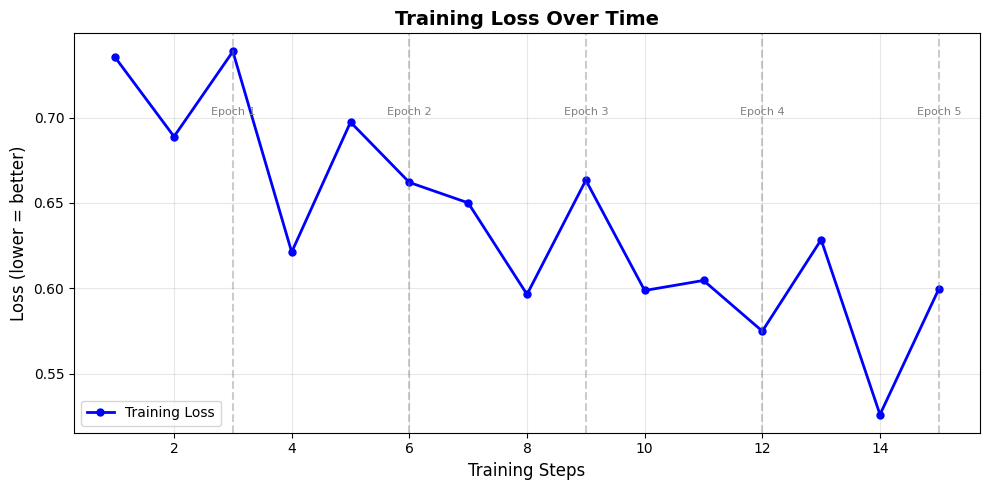

Starting loss: 0.7352
Final loss:    0.5996
Improvement:   0.1356 (18% reduction)


In [11]:
# Visualize the training loss curve
import matplotlib.pyplot as plt

# Extract loss values from trainer's log history
train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
train_steps = [log['step'] for log in trainer.state.log_history if 'loss' in log]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_steps, train_losses, 'b-o', linewidth=2, markersize=5, label='Training Loss')

# Epoch markers
steps_per_epoch = len(tokenized_dataset) // training_args.per_device_train_batch_size
for epoch in range(1, 6):
    epoch_step = epoch * steps_per_epoch
    if epoch_step <= max(train_steps):
        ax.axvline(x=epoch_step, color='gray', linestyle='--', alpha=0.4)
        ax.text(epoch_step, max(train_losses) * 0.95, f'Epoch {epoch}', fontsize=8, color='gray', ha='center')

ax.set_xlabel('Training Steps', fontsize=12)
ax.set_ylabel('Loss (lower = better)', fontsize=12)
ax.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Starting loss: {train_losses[0]:.4f}")
print(f"Final loss:    {train_losses[-1]:.4f}")
print(f"Improvement:   {train_losses[0] - train_losses[-1]:.4f} ({(1 - train_losses[-1]/train_losses[0])*100:.0f}% reduction)")

## Step 6: Test the Fine-Tuned Model

Let's see how our trained model performs — first on the **held-out test data**, then on completely new reviews.

In [12]:
# Evaluate on held-out test data
eval_results = trainer.evaluate()
print(f"Test set accuracy: {eval_results['eval_accuracy']:.0%}")

Test set accuracy: 75%


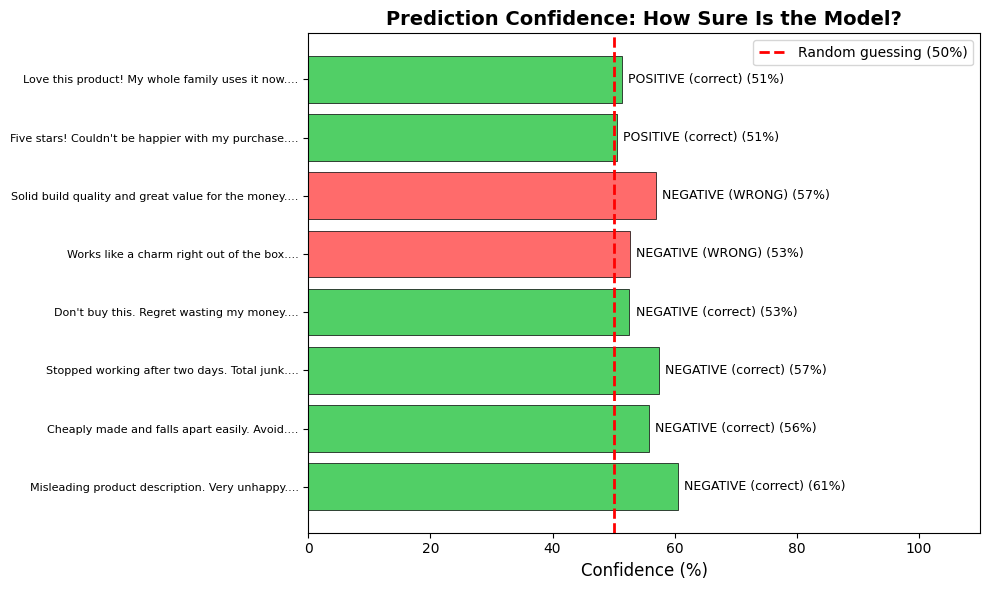


Accuracy: 75% (6/8 correct)
Average confidence: 54.7%

With only 12 training examples for 66M parameters, the model has limited data to learn from.
More training data would likely improve both accuracy and confidence.


In [13]:
# Visualize prediction confidence on test set
import matplotlib.pyplot as plt

# Collect predictions on test data
predictions = []
for ex in test_examples:
    sentiment, confidence = predict_sentiment(ex['text'])
    expected = "POSITIVE" if ex['label'] == 1 else "NEGATIVE"
    correct = sentiment == expected
    predictions.append({'text': ex['text'][:50], 'predicted': sentiment, 'expected': expected,
                        'confidence': confidence, 'correct': correct})

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#51cf66' if p['correct'] else '#ff6b6b' for p in predictions]
labels = [f"{p['text']}..." for p in predictions]
confidences = [p['confidence'] * 100 for p in predictions]
pred_labels = [f"{p['predicted']} ({'correct' if p['correct'] else 'WRONG'})" for p in predictions]

y_pos = range(len(predictions))
bars = ax.barh(y_pos, confidences, color=colors, edgecolor='black', linewidth=0.5)

# Add prediction label on each bar
for i, (conf, pred) in enumerate(zip(confidences, pred_labels)):
    ax.text(conf + 1, i, f"{pred} ({conf:.0f}%)", va='center', fontsize=9)

# Random baseline
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Random guessing (50%)')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Confidence (%)', fontsize=12)
ax.set_title('Prediction Confidence: How Sure Is the Model?', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

accuracy = sum(p['correct'] for p in predictions) / len(predictions)
avg_conf = sum(p['confidence'] for p in predictions) / len(predictions)
print(f"\nAccuracy: {accuracy:.0%} ({sum(p['correct'] for p in predictions)}/{len(predictions)} correct)")
print(f"Average confidence: {avg_conf:.1%}")
if avg_conf < 0.75:
    print("\nWith only 12 training examples for 66M parameters, the model has limited data to learn from.")
    print("More training data would likely improve both accuracy and confidence.")
else:
    print("\nThe model learned something from just 12 examples!")
    print("With more training data, performance would likely improve further.")

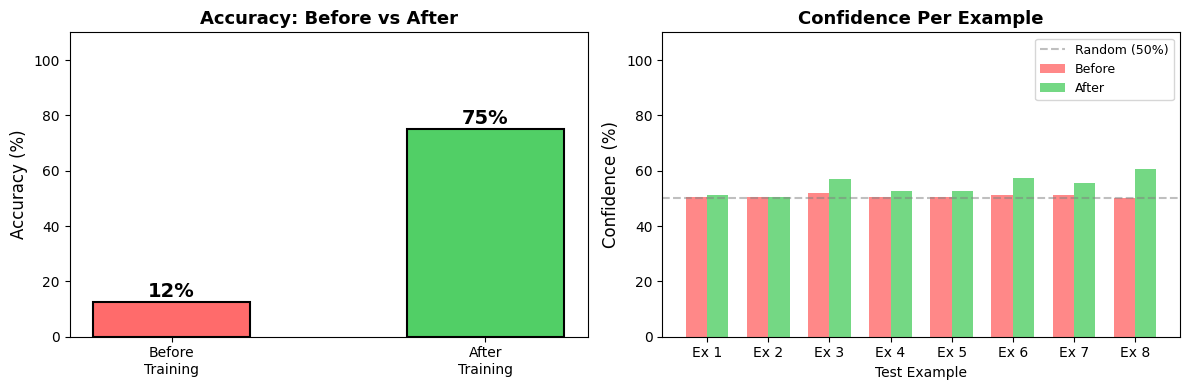

In [14]:
# Before vs After: Compare baseline to trained model
import matplotlib.pyplot as plt

# Get trained model predictions on the same test set
trained_results = []
for ex in test_examples:
    sentiment, confidence = predict_sentiment(ex['text'])
    expected = "POSITIVE" if ex['label'] == 1 else "NEGATIVE"
    trained_results.append({'text': ex['text'][:40], 'predicted': sentiment, 'expected': expected,
                            'confidence': confidence, 'correct': sentiment == expected})

# Build comparison chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Accuracy comparison
baseline_acc = sum(r['correct'] for r in baseline_results) / len(baseline_results) * 100
trained_acc = sum(r['correct'] for r in trained_results) / len(trained_results) * 100
bars = axes[0].bar(['Before\nTraining', 'After\nTraining'], [baseline_acc, trained_acc],
                    color=['#ff6b6b', '#51cf66'], edgecolor='black', linewidth=1.5, width=0.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy: Before vs After', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, [baseline_acc, trained_acc]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.0f}%',
                 ha='center', fontsize=14, fontweight='bold')

# Panel 2: Confidence comparison
baseline_confs = [r['confidence'] * 100 for r in baseline_results]
trained_confs = [r['confidence'] * 100 for r in trained_results]
x = range(len(test_examples))
width = 0.35
axes[1].bar([i - width/2 for i in x], baseline_confs, width, label='Before', color='#ff6b6b', alpha=0.8)
axes[1].bar([i + width/2 for i in x], trained_confs, width, label='After', color='#51cf66', alpha=0.8)
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random (50%)')
axes[1].set_xlabel('Test Example')
axes[1].set_ylabel('Confidence (%)', fontsize=12)
axes[1].set_title('Confidence Per Example', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([f"Ex {i+1}" for i in x])
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

---

## Exercises (Optional)

The exercises below are **optional** — for those who want to explore further. The key concepts (pre-training vs fine-tuning, how training works, what the loss curve means) are all covered in the walkthrough above.

# Exercise 1: Add Your Own Training Examples

Add **5 new reviews** to the training data below — at least 2 positive and 2 negative.

Think about reviews that might be challenging for the model:
- **Ambiguous**: "It's fine, I guess. Not what I expected but it works." (Is this positive or negative?)
- **Sarcastic**: "Oh great, another product that breaks in a week. Just what I needed."
- **Domain-specific**: "The 4K resolution is stunning but the refresh rate causes ghosting."
- **Mixed sentiment**: "Love the design, hate the battery life."
- **Subtle negativity**: "The product is exactly as described in the listing." (neutral or positive?)

**After adding your examples**, run all the cells below to retrain the model.

In [15]:
# YOUR CODE: Add 5 new training examples here!

my_examples = [
    # Add your examples below (at least 2 positive, 2 negative)
    # Format: {"text": "Your review here", "label": 1}  # 1 = positive
    # Format: {"text": "Your review here", "label": 0}  # 0 = negative

    # Example (delete this and add your own):
    # {"text": "This laptop runs so smoothly!", "label": 1},

]

# Combine with original training data
combined_data = training_examples + my_examples

print(f"Combined training data: {len(combined_data)} examples")
print(f"- Original: {len(training_examples)}")
print(f"- Your additions: {len(my_examples)}")

Combined training data: 12 examples
- Original: 12
- Your additions: 0


In [16]:
# Retrain with combined data (only run this after adding your examples!)
if len(my_examples) >= 5:
    print("Retraining model with your examples...\n")

    # Reload fresh model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2,
        id2label={0: "NEGATIVE", 1: "POSITIVE"},
        label2id={"NEGATIVE": 0, "POSITIVE": 1}
    )

    # Prepare new dataset
    new_dataset = Dataset.from_list(combined_data)
    new_tokenized = new_dataset.map(tokenize, batched=True)

    # Train
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=new_tokenized,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics,
    )
    trainer.train()

    # Evaluate on held-out test data
    eval_results = trainer.evaluate()
    print(f"\nRetrained with your examples!")
    print(f"Test set accuracy: {eval_results['eval_accuracy']:.0%}")
else:
    print("Please add at least 5 examples to my_examples list above!")

Please add at least 5 examples to my_examples list above!


---

# Exercise 2: Test on Your Own Text

Write **3 product reviews** to test the model. Try to find cases where the model might be wrong!

In [17]:
# YOUR CODE: Test your own reviews!

my_test_reviews = [
    # Add your test reviews here:
    "Your first review here",
    "Your second review here",
    "Your third review here",
]

if any("Your" in r and "review here" in r for r in my_test_reviews):
    print("Please replace the placeholder reviews above with your own text!")
else:
  print("Testing your reviews:\n")
  for review in my_test_reviews:
      sentiment, confidence = predict_sentiment(review)
      print(f"Review: \"{review}\"")
      print(f"Prediction: {sentiment} (confidence: {confidence:.1%})")
      print("-" * 60)

Please replace the placeholder reviews above with your own text!


---

# Exercise 3: Compare Before and After

Think about the difference between using a pre-trained model vs. your fine-tuned model.

**Answer these questions** (edit the text below):

### Your Answers:

**Q1: Did the model correctly classify all your test reviews? Which ones did it get wrong and why do you think that happened?**

*Your answer here:*

---

**Q2: The model was trained on only 12 examples and tested on 8 held-out examples. What are the risks of evaluating on such a small test set? How might the results change with 100 or 1000 test examples?**

*Your answer here:*

---

**Q3: When would a company choose fine-tuning vs. just using better prompts with ChatGPT? Name one advantage of each approach.**

*Your answer here:*

---

## Congratulations!

You've successfully:
- Fine-tuned a language model for sentiment classification
- Evaluated on held-out test data (not just training data!)
- Added your own training examples and retrained
- Tested the model on custom inputs
- Thought about business applications of fine-tuning

**Next**: Complete Task 2 to compare prompting approaches!